# Step 5 — Ensemble and honest evaluation

**Goal:** combine Elo, Dixon-Coles and the neural network into one forecast, and check, honestly, whether it beats simple baselines.

**Why an ensemble?** Each model sees the game differently: Elo tracks overall strength, Dixon-Coles models goals, and the network uses form. When models make *different* mistakes, averaging them usually cancels some of those mistakes out.

**How we keep it honest:**
1. Choose the ensemble weights on the **validation** set only.
2. Score the final ensemble on the **2026 World Cup** (the test set) **once**. No going back to tweak it after seeing the test results.

## 1. Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 4)

# Save everything in Google Drive, so each notebook can use the previous notebook's outputs.
# Colab will ask for permission to access your Drive the first time.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/world-cup-prediction"
except ImportError:          # running on your own computer instead of Colab
    BASE = "."
os.makedirs(BASE, exist_ok=True)
os.chdir(BASE)
for folder in ["data", "models", "preds"]:
    os.makedirs(folder, exist_ok=True)
print("Working folder:", os.getcwd())

Mounted at /content/drive
Working folder: /content/drive/MyDrive/world-cup-prediction


In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
START_YEAR = 1990

def load_matches():
    """Load cleaned matches (downloading and cleaning them first if needed)."""
    path = "data/matches_clean.csv"
    if not os.path.exists(path):
        raw = pd.read_csv(URL, parse_dates=["date"])
        df = raw.dropna(subset=["home_score", "away_score"])
        df = df[df["date"].dt.year >= START_YEAR].copy()
        df.to_csv(path, index=False)
    df = pd.read_csv(path, parse_dates=["date"])
    df = df.sort_values(["date", "home_team", "away_team"], kind="stable").reset_index(drop=True)
    df["match_id"] = df.index
    df["home_score"] = df["home_score"].astype(int)
    df["away_score"] = df["away_score"].astype(int)
    df["neutral"] = df["neutral"].astype(bool)
    # Result coded as a class: 0 = home win, 1 = draw, 2 = away win
    df["result"] = np.select([df["home_score"] > df["away_score"],
                              df["home_score"] < df["away_score"]], [0, 2], default=1)
    return df

def add_splits(df):
    """train: before 2024 | val: 2024 until the World Cup | test: the 2026 World Cup matches."""
    wc26 = (df["tournament"] == "FIFA World Cup") & (df["date"].dt.year == 2026)
    test_start = df.loc[wc26, "date"].min() if wc26.any() else pd.Timestamp("2026-06-11")
    val_start = pd.Timestamp("2024-01-01")
    df["split"] = np.select([df["date"] < val_start, df["date"] < test_start, wc26],
                            ["train", "val", "test"], default="after")
    return df, val_start, test_start

matches, VAL_START, TEST_START = add_splits(load_matches())
print(matches["split"].value_counts().to_string())
print("Validation starts:", VAL_START.date(), "| Test (World Cup 2026) starts:", TEST_START.date())

split
train    29787
val       2564
after      366
test       104
Validation starts: 2024-01-01 | Test (World Cup 2026) starts: 2026-06-11


## Train / validation / test split

To judge the models honestly, they must be tested on matches they have **never seen**:

| Split | Matches | Used for |
| --- | --- | --- |
| **train** | before 2024 | fitting the models |
| **val** | 2024 → start of World Cup 2026 | comparing models and tuning settings |
| **test** | the 2026 World Cup itself | the final, one-time exam |

Splitting by **time** (not randomly) matters in sport: a model must never learn from the future.

In [3]:
missing = [f for f in ["preds/elo_preds.csv", "preds/dc_preds.csv", "preds/nn_preds.csv"] if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Run notebooks 02–04 first. Missing: {missing}")

PCOLS = ["p_home", "p_draw", "p_away"]
MODELS = ["elo", "dc", "nn"]
df = matches[matches["split"].isin(["val", "test"])][["match_id", "date", "home_team", "away_team",
                                                      "home_score", "away_score", "result", "split"]]
for name in MODELS:
    p = pd.read_csv(f"preds/{name}_preds.csv")[["match_id"] + PCOLS]
    df = df.merge(p.rename(columns={c: f"{name}_{c}" for c in PCOLS}), on="match_id")

probs = {name: df[[f"{name}_{c}" for c in PCOLS]].values for name in MODELS}
is_val, is_test = (df["split"] == "val").values, (df["split"] == "test").values
y = df["result"].values
print(f"validation matches: {is_val.sum():,} | World Cup matches: {is_test.sum()}")

validation matches: 2,564 | World Cup matches: 104


## 2. Metrics and baselines

We use three metrics:
- **Log loss** (main metric): rewards confident correct probabilities and punishes confident mistakes hard. Lower is better.
- **Brier score:** the average squared error of the probabilities. Lower is better.
- **Accuracy:** how often the most likely outcome happened. Easy to understand, but it ignores how confident the model was.

A model is only useful if it beats **baselines**:
- **Uniform:** ⅓ for every outcome (knows nothing).
- **Base rates:** the historical share of home wins, draws and away wins (knows only history).

In [4]:
from sklearn.metrics import log_loss

def brier(y_true, p):
    onehot = np.eye(3)[y_true]
    return np.mean(np.sum((p - onehot) ** 2, axis=1))

def evaluate(y_true, p):
    return {"log loss": log_loss(y_true, p, labels=[0, 1, 2]),
            "Brier": brier(y_true, p),
            "accuracy": np.mean(p.argmax(axis=1) == y_true)}

base_rates = matches.loc[matches["split"] == "train", "result"].value_counts(normalize=True).sort_index().values
n = len(df)
probs["uniform"] = np.full((n, 3), 1 / 3)
probs["base rates"] = np.tile(base_rates, (n, 1))

pd.DataFrame({name: evaluate(y[is_val], probs[name][is_val])
              for name in ["uniform", "base rates", "elo", "dc", "nn"]}).T.round(4)

,log loss,Brier,accuracy
uniform,1.0986,0.6667,0.4739
base rates,1.0541,0.6359,0.4739
elo,0.8693,0.5117,0.5967
dc,0.8615,0.5044,0.6030
nn,0.8623,0.5071,0.6030


## 3. Find the best ensemble weights (validation set only)

We try every combination of weights in steps of 0.05 that adds up to 1, and keep the one with the lowest validation log loss.

In [5]:
best = (None, float("inf"))
grid = np.round(np.arange(0, 1.0001, 0.05), 2)
for w_elo in grid:
    for w_dc in grid:
        w_nn = round(1 - w_elo - w_dc, 2)
        if w_nn < 0:
            continue
        p = w_elo * probs["elo"] + w_dc * probs["dc"] + w_nn * probs["nn"]
        loss = log_loss(y[is_val], p[is_val], labels=[0, 1, 2])
        if loss < best[1]:
            best = ({"elo": float(w_elo), "dc": float(w_dc), "nn": float(w_nn)}, loss)

WEIGHTS = best[0]
print("Best weights:", WEIGHTS, f"| validation log loss {best[1]:.4f}")
probs["ensemble"] = sum(WEIGHTS[m] * probs[m] for m in MODELS)

Best weights: {'elo': 0.05, 'dc': 0.55, 'nn': 0.4} | validation log loss 0.8523


## 4. Are the probabilities trustworthy? (calibration)

If the model says "60% home win" for a group of matches, about 60% of them should actually be home wins. A **calibration plot** checks this: a well-calibrated model sits close to the diagonal line.

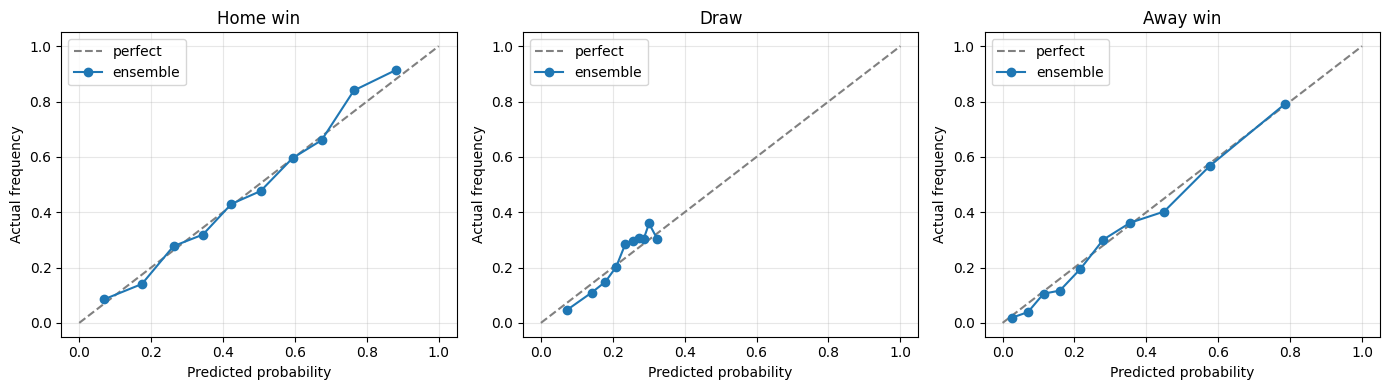

Average predicted draw probability: 22.7% | actual draw rate: 23.6%


In [6]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ax, label) in enumerate(zip(axes, ["Home win", "Draw", "Away win"])):
    frac, mean_pred = calibration_curve((y[is_val] == i).astype(int), probs["ensemble"][is_val, i],
                                        n_bins=10, strategy="quantile")
    ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
    ax.plot(mean_pred, frac, "o-", label="ensemble")
    ax.set_title(label); ax.set_xlabel("Predicted probability"); ax.set_ylabel("Actual frequency")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Average predicted draw probability: {probs['ensemble'][is_val, 1].mean():.1%} "
      f"| actual draw rate: {(y[is_val] == 1).mean():.1%}")

## 5. The final exam: the 2026 World Cup

Now, and only once, we score every model on the World Cup matches. With around 100 matches the results are noisy, so small differences between models aren't meaningful.

In [7]:
if is_test.sum() == 0:
    print("No 2026 World Cup matches found in the data.")
else:
    final = pd.DataFrame({name: evaluate(y[is_test], probs[name][is_test])
                          for name in ["uniform", "base rates", "elo", "dc", "nn", "ensemble"]}).T.round(4)
    display(final)

,log loss,Brier,accuracy
uniform,1.0986,0.6667,0.4712
base rates,1.0546,0.6365,0.4712
elo,0.8529,0.5028,0.6442
dc,0.8320,0.4895,0.6635
nn,0.8573,0.5030,0.6250
ensemble,0.8359,0.4913,0.6538


In [8]:
# Biggest surprises of the tournament according to the ensemble
if is_test.sum() > 0:
    t = df[is_test].copy()
    t["prob_of_actual"] = probs["ensemble"][is_test][np.arange(is_test.sum()), y[is_test]]
    t["score"] = t["home_score"].astype(str) + "-" + t["away_score"].astype(str)
    display(t.nsmallest(5, "prob_of_actual")[["date", "home_team", "away_team", "score", "prob_of_actual"]])

,date,home_team,away_team,score,prob_of_actual
2579,2026-06-15,Spain,Cape Verde,0-0,0.099593
2571,2026-06-13,Qatar,Switzerland,1-1,0.143398
2596,2026-06-20,Ecuador,Curaçao,0-0,0.145828
2609,2026-06-23,England,Ghana,0-0,0.163706
2617,2026-06-24,South Africa,South Korea,1-0,0.175403


## 6. Save the weights for the simulation

In [9]:
json.dump(WEIGHTS, open("models/ensemble_weights.json", "w"))
print("Saved models/ensemble_weights.json")

Saved models/ensemble_weights.json
